# Inference Algorithms & Causal Interventions
### `02_PGM_Causal_Logic/Inference_Algorithms_and_Causality/`

> **Learning goal:** Finish the causal-logic stack begun in `Belief_Architecture.ipynb`. Implement **Belief Propagation**, **MCMC** (Metropolis–Hastings + Gibbs), and **Pearl's do-calculus** (interventional vs observational queries) from scratch — then connect each algorithm to how a world-model agent would use it.

> **Prerequisites:** Bayes' rule, Bayesian networks, d-separation, variable elimination (see `Belief_Architecture.ipynb`).

> **Primary references:** Murphy *PML* Ch. 9–12; Koller & Friedman *PGMs* Ch. 9–12; Pearl *Causality* Ch. 1–3.

---

## Map of This Notebook

| Section | Algorithm | Exact / Approx | When you use it |
|---|---|---|---|
| 1 | Belief Propagation (sum-product) | Exact on trees | Chain / tree factor graphs; Kalman / HMM special cases |
| 2 | Loopy BP (intuition + demo) | Approximate | Graphs with cycles; early vision / turbo codes |
| 3 | Metropolis–Hastings MCMC | Approximate | Arbitrary joint; hard to factor / high treewidth |
| 4 | Gibbs sampling | Approximate | When conditionals $P(x_i \mid x_{-i})$ are easy |
| 5 | do-calculus + backdoor | Exact (if graph known) | Interventional queries: "what if I force $X$?" |
| 6 | Bridge to world models | — | Planning under partial observability |

---

## 1. Belief Propagation — Message Passing on Trees

### 1A. Why messages?

Variable elimination recomputes large intermediate factors for every query. On a **tree**, you can cache intermediate results as **messages** between neighbours and answer *all* marginals with two sweeps (leaves → root → leaves).

For undirected pairwise factor graph (nodes $i$ with unary potentials $\phi_i$, edges $ij$ with pairwise $\psi_{ij}$):

$$
\mu_{i \to j}(x_j)
=
\sum_{x_i}
\phi_i(x_i)\,
\psi_{ij}(x_i,x_j)
\prod_{k \in \mathrm{Ne}(i)\setminus j}
\mu_{k \to i}(x_i)
$$

After all messages converge, the **belief** (unnormalized marginal) is

$$
b_i(x_i)
\propto
\phi_i(x_i)
\prod_{j \in \mathrm{Ne}(i)}
\mu_{j \to i}(x_i).
$$

**Special cases you already know:**
- HMM forward–backward = BP on a chain.
- Kalman filter / RTS smoother = BP on a Gaussian chain.
- Transformer *attention* is **not** BP — it is a learned soft routing over a complete graph, with no guarantee of marginal correctness.

### 1B. Complexity

On a tree with $n$ nodes and max domain size $d$: $\mathcal{O}(n\,d^2)$ for pairwise factors. Compare variable elimination treewidth bound $\mathcal{O}(n\,d^{w+1})$.

### 1C. AI relevance

In a world model, the latent dynamics graph is often **tree-like over short horizons** (Markov chain) or a **tree of futures** (search). BP is the exact engine for "given what I observed, what is my belief over latent causes?" — the same object an agent conditions on before planning.

True latent : [0 0 1 1 1]
Noisy obs   : [0 0 0 0 1]
P(X_i=1 | obs) from BP:
  i=0: 0.065   (MAP=0)
  i=1: 0.047   (MAP=0)
  i=2: 0.059   (MAP=0)
  i=3: 0.118   (MAP=0)
  i=4: 0.303   (MAP=0)


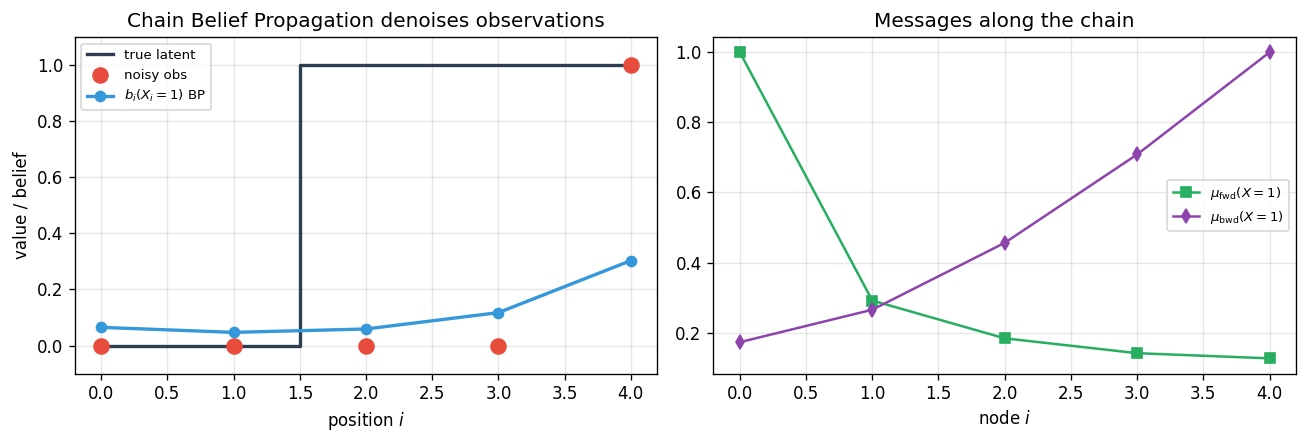

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# ── Pairwise chain (tree) BP for a 1D Ising / binary HMM ─────────────────────
# Variables X0 — X1 — X2 — X3 — X4, each in {0,1}
# Unary: prefer label from a noisy observation
# Pairwise: prefer neighbouring labels equal (smoothness)

def normalize(v):
    s = v.sum()
    return v / s if s > 0 else np.ones_like(v) / len(v)

def build_chain_factors(obs, noise=0.2, couple=1.5):
    """Unary phi[i][x], pairwise psi[i][x,y] for edge (i,i+1)."""
    n = len(obs)
    phi = []
    for o in obs:
        # P(obs | x): obs flips with prob noise
        p0 = (1 - noise) if o == 0 else noise
        p1 = (1 - noise) if o == 1 else noise
        phi.append(np.array([p0, p1], dtype=float))
    # pairwise: exp(couple * 1[x==y])
    base = np.array([[np.exp(couple), np.exp(-couple)],
                     [np.exp(-couple), np.exp(couple)]], dtype=float)
    psi = [base.copy() for _ in range(n - 1)]
    return phi, psi

def belief_propagation_chain(phi, psi, n_iters=1):
    """Exact BP on a chain: one forward + one backward pass."""
    n = len(phi)
    # messages: fwd[i] = mu_{i-1 -> i}  (shape 2,), bwd[i] = mu_{i+1 -> i}
    fwd = [np.ones(2) for _ in range(n)]
    bwd = [np.ones(2) for _ in range(n)]

    # forward: leaves to right
    for i in range(n - 1):
        # mu_{i -> i+1}(x_{i+1}) = sum_{xi} phi_i(xi) * psi_i(xi, x{i+1}) * fwd[i](xi)
        #                                 * (no left products beyond fwd)
        left = phi[i] * fwd[i]
        msg = np.zeros(2)
        for xj in (0, 1):
            msg[xj] = (left * psi[i][:, xj]).sum()
        fwd[i + 1] = normalize(msg)

    # backward
    for i in range(n - 1, 0, -1):
        right = phi[i] * bwd[i]
        msg = np.zeros(2)
        for xi in (0, 1):
            msg[xi] = (right * psi[i - 1][xi, :]).sum()
        bwd[i - 1] = normalize(msg)

    beliefs = []
    for i in range(n):
        b = normalize(phi[i] * fwd[i] * bwd[i])
        beliefs.append(b)
    return beliefs, fwd, bwd

# Noisy observations of a smooth latent path 0,0,1,1,1
true = np.array([0, 0, 1, 1, 1])
rng = np.random.default_rng(0)
flip = rng.random(len(true)) < 0.25
obs = true.copy()
obs[flip] = 1 - obs[flip]

phi, psi = build_chain_factors(obs, noise=0.25, couple=1.2)
beliefs, fwd, bwd = belief_propagation_chain(phi, psi)

print("True latent :", true)
print("Noisy obs   :", obs)
print("P(X_i=1 | obs) from BP:")
for i, b in enumerate(beliefs):
    print(f"  i={i}: {b[1]:.3f}   (MAP={int(b[1] > 0.5)})")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
ax.step(range(len(true)), true, where="mid", lw=2, label="true latent", color="#2C3E50")
ax.scatter(range(len(obs)), obs, s=80, c="#E74C3C", zorder=5, label="noisy obs")
ax.plot(range(len(beliefs)), [b[1] for b in beliefs], "o-", color="#3498DB",
        lw=2, label=r"$b_i(X_i=1)$ BP")
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel("position $i$")
ax.set_ylabel("value / belief")
ax.set_title("Chain Belief Propagation denoises observations")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
# show forward messages magnitude of preferring 1
fwd1 = [m[1] for m in fwd]
bwd1 = [m[1] for m in bwd]
ax.plot(fwd1, "s-", label=r"$\mu_{\mathrm{fwd}}(X=1)$", color="#27AE60")
ax.plot(bwd1, "d-", label=r"$\mu_{\mathrm{bwd}}(X=1)$", color="#8E44AD")
ax.set_title("Messages along the chain")
ax.set_xlabel("node $i$")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("INF_A_belief_propagation_chain.png", dpi=150, bbox_inches="tight")
plt.show()

### Takeaway — BP

BP turns the global sum-product into **local message updates**. On trees it is exact; the messages are the same intermediate factors variable elimination would build, just cached for reuse.

**World-model reading:** your latent state over time is a chain. Filtering = forward messages; smoothing = forward + backward. Dreamer / RSSM style models implement a *learned*, amortized version of this idea (encoder = approximate message from observations).

## 2. Loopy BP — Approximate Messages on Cycles

When the graph has cycles, the BP fixed-point equations are no longer guaranteed to give exact marginals. You still iterate messages; if they converge, the beliefs are often good approximations (especially for weak coupling).

**When loopy BP fails:** strong frustrated loops (e.g. antiferromagnetic triangles), multi-modal posteriors.

**AI link:** early error-correcting codes (turbo / LDPC) and some vision CRFs used loopy BP successfully — proof that approximate message passing can be engineering-grade even without exactness theorems for the general case.

Attractive triangle beliefs P(X=1): {0: 0.19864029455117854, 1: 0.2059463673178854, 2: 0.21325018698776546}
Frustrated triangle beliefs P(X=1): {0: 0.4771905518345316, 1: 0.49535370837939713, 2: 0.5135163760526147}


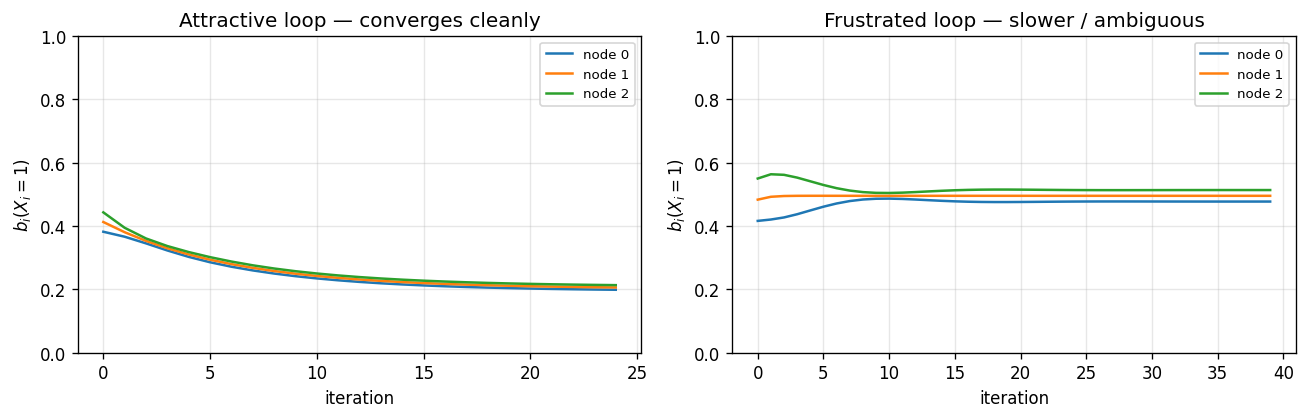

In [2]:
# ── Loopy BP on a 3-node cycle (frustrated Ising triangle) ───────────────────

def loopy_bp_pairwise(nodes, edges, phi, psi, n_iters=20, damp=0.5):
    """
    nodes: list of node ids
    edges: list of (i,j) undirected pairs
    phi[i]: array over domain
    psi[(i,j)]: matrix psi[xi, xj]  (store both orientations as same matrix)
    """
    domain = {i: len(phi[i]) for i in nodes}
    # messages mu[(i,j)] = message i -> j
    mu = {}
    for i, j in edges:
        mu[(i, j)] = np.ones(domain[j]) / domain[j]
        mu[(j, i)] = np.ones(domain[i]) / domain[i]

    history = []
    for it in range(n_iters):
        new_mu = {}
        for i, j in list(edges) + [(j, i) for i, j in edges]:
            # message i -> j
            neigh = [k for k in nodes if ((i, k) in mu or (k, i) in mu) and k != j]
            # products of incoming messages to i except from j
            inc = phi[i].copy()
            for k in nodes:
                if k == i or k == j:
                    continue
                if (k, i) in mu:
                    inc = inc * mu[(k, i)]
            # need psi for edge i-j
            if (i, j) in psi:
                pot = psi[(i, j)]
            else:
                pot = psi[(j, i)].T
            msg = np.zeros(domain[j])
            for xj in range(domain[j]):
                msg[xj] = (inc * pot[:, xj]).sum()
            msg = normalize(msg)
            old = mu[(i, j)]
            new_mu[(i, j)] = normalize((1 - damp) * old + damp * msg)
        mu.update(new_mu)
        # beliefs
        bel = {}
        for i in nodes:
            b = phi[i].copy()
            for k in nodes:
                if k != i and (k, i) in mu:
                    b = b * mu[(k, i)]
            bel[i] = normalize(b)
        history.append({i: bel[i][1] for i in nodes})
    return bel, history

# Attractive triangle: all want to agree — easy
nodes = [0, 1, 2]
edges = [(0, 1), (1, 2), (2, 0)]
phi_t = {
    0: np.array([0.6, 0.4]),
    1: np.array([0.55, 0.45]),
    2: np.array([0.5, 0.5]),
}
agree = np.array([[np.exp(1.0), np.exp(-1.0)],
                  [np.exp(-1.0), np.exp(1.0)]])
psi_attr = {(0, 1): agree, (1, 2): agree, (2, 0): agree}
bel_a, hist_a = loopy_bp_pairwise(nodes, edges, phi_t, psi_attr, n_iters=25)

# Frustrated triangle: edges want disagree — multi-modal / hard
disagree = np.array([[np.exp(-1.2), np.exp(1.2)],
                     [np.exp(1.2), np.exp(-1.2)]])
psi_fr = {(0, 1): disagree, (1, 2): disagree, (2, 0): disagree}
bel_f, hist_f = loopy_bp_pairwise(nodes, edges, phi_t, psi_fr, n_iters=40, damp=0.4)

print("Attractive triangle beliefs P(X=1):", {i: float(bel_a[i][1]) for i in nodes})
print("Frustrated triangle beliefs P(X=1):", {i: float(bel_f[i][1]) for i in nodes})

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, hist, title in [
    (axes[0], hist_a, "Attractive loop — converges cleanly"),
    (axes[1], hist_f, "Frustrated loop — slower / ambiguous"),
]:
    for i in nodes:
        ax.plot([h[i] for h in hist], label=f"node {i}")
    ax.set_xlabel("iteration")
    ax.set_ylabel(r"$b_i(X_i=1)$")
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("INF_B_loopy_bp.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Metropolis–Hastings MCMC

When the graph has high treewidth, exact inference is exponential. **MCMC** draws samples from $P(x)$ and estimates expectations by averages.

### 3A. Metropolis–Hastings

Propose $x' \sim q(x' \mid x)$, accept with

$$
A(x \to x')
=
\min\!\left(
1,\;
\frac{P(x')\,q(x \mid x')}{P(x)\,q(x' \mid x)}
\right).
$$

If $q$ is symmetric ($q(x'|x)=q(x|x')$), this reduces to Metropolis: accept iff $P(x') \ge P(x)$ or with probability $P(x')/P(x)$.

**Detailed balance** $\Rightarrow$ stationary distribution is $P$.

### 3B. Practical checklist

1. **Burn-in:** discard early samples before stationarity.
2. **Thinning (optional):** keep every $k$-th sample if autocorrelation is high.
3. **Multiple chains:** Gelman–Rubin $\hat{R}$ diagnostic.
4. **Only need unnormalized $P$:** the partition function $Z$ cancels in the ratio.

### 3C. AI relevance

- Bayesian neural nets / deep ensembles ≈ approximate posterior samples.
- Energy-based models train so that MCMC (or amortized samplers) can draw from $p_\theta$.
- In causal discovery / structure learning, MH over DAGs is a classic approach.

MH accept rate: 0.627
Empirical mean after burn-in: [-0.2519 -0.0294]
Mode occupation left/right: 0.55 / 0.45


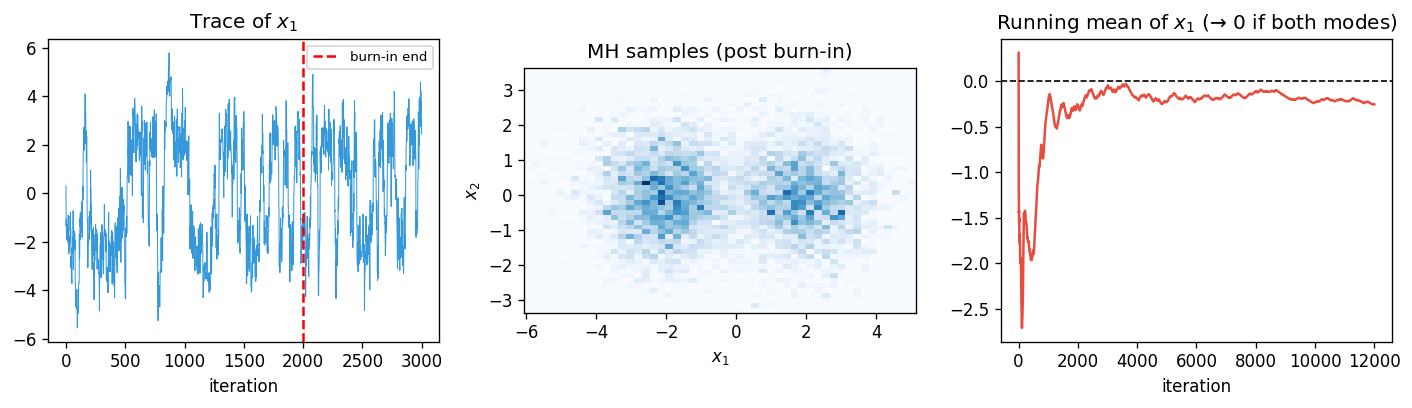

In [3]:
# ── MH sampling of a 2D Gaussian mixture (bimodal posterior toy) ─────────────

def log_p_gmm(x):
    """Unnormalized log-density of equal mixture of two Gaussians."""
    # components at (-2,0) and (+2,0)
    d1 = np.sum((x - np.array([-2.0, 0.0])) ** 2)
    d2 = np.sum((x - np.array([2.0, 0.0])) ** 2)
    # log-sum-exp
    a = -0.5 * d1
    b = -0.5 * d2
    m = max(a, b)
    return m + np.log(np.exp(a - m) + np.exp(b - m))

def metropolis_hastings(log_p, x0, n_samples=8000, step=0.8, seed=1):
    rng = np.random.default_rng(seed)
    x = np.asarray(x0, dtype=float)
    samples = np.zeros((n_samples, x.size))
    accepts = 0
    cur = log_p(x)
    for t in range(n_samples):
        prop = x + step * rng.normal(size=x.size)
        lp = log_p(prop)
        if np.log(rng.random()) < (lp - cur):
            x, cur = prop, lp
            accepts += 1
        samples[t] = x
    return samples, accepts / n_samples

samples, acc = metropolis_hastings(log_p_gmm, x0=np.array([0.0, 0.0]),
                                   n_samples=12000, step=0.9)
burn = 2000
keep = samples[burn:]
print(f"MH accept rate: {acc:.3f}")
print(f"Empirical mean after burn-in: {keep.mean(axis=0)}")
print(f"Mode occupation left/right: "
      f"{(keep[:,0] < 0).mean():.2f} / {(keep[:,0] >= 0).mean():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].plot(samples[:3000, 0], lw=0.6, color="#3498DB")
axes[0].axvline(burn, color="red", ls="--", label="burn-in end")
axes[0].set_title("Trace of $x_1$")
axes[0].legend(fontsize=8)
axes[0].set_xlabel("iteration")

axes[1].hist2d(keep[:, 0], keep[:, 1], bins=50, cmap="Blues")
axes[1].set_title("MH samples (post burn-in)")
axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$")
axes[1].set_aspect("equal")

# running mean of x1 — should approach ~0 if both modes visited
running = np.cumsum(samples[:, 0]) / np.arange(1, len(samples) + 1)
axes[2].plot(running, color="#E74C3C")
axes[2].axhline(0.0, color="k", ls="--", lw=1)
axes[2].set_title("Running mean of $x_1$ (→ 0 if both modes)")
axes[2].set_xlabel("iteration")
plt.tight_layout()
plt.savefig("INF_C_metropolis_hastings.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Gibbs Sampling

Gibbs is MH with a special proposal: resample one coordinate from its **full conditional**

$$
x_i^{(t+1)} \sim P\!\left(x_i \mid x_{-i}^{(t)}\right).
$$

Acceptance probability is always 1. Ideal when conditionals are closed-form (Ising, many conjugate Bayesian models, LDA).

### Full conditionals for a Bayesian network

For a BN, the full conditional of $X_i$ depends only on its **Markov blanket**:

$$
P(x_i \mid x_{-i})
\propto
P(x_i \mid \mathrm{Pa}_i)
\prod_{c \in \mathrm{Ch}_i}
P(x_c \mid \mathrm{Pa}_c).
$$

This is why the Markov blanket section in `Belief_Architecture` was not decorative — it is the computational locality of Gibbs.

Observational P(R=1 | W=1) ≈ 0.697
Observational P(S=1 | W=1) ≈ 0.441


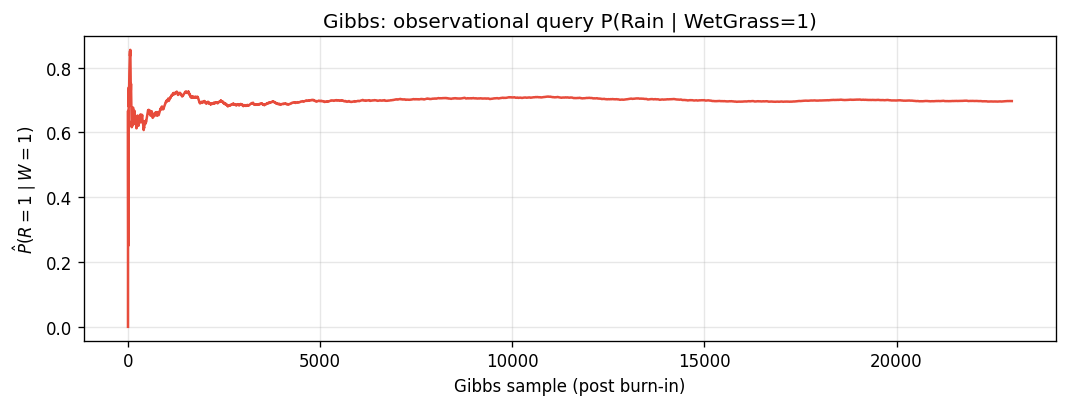

In [4]:
# ── Gibbs on the classic Sprinkler BN ────────────────────────────────────────
# Cloudy -> Rain, Cloudy -> Sprinkler, Rain -> WetGrass, Sprinkler -> WetGrass
# Binary variables; CPTs from the standard teaching example (approx).

# Order: C, R, S, W
# CPTs as dicts of tuples of parent values -> P(var=1)

P_C = 0.5
P_R_given_C = {0: 0.2, 1: 0.8}          # P(R=1|C)
P_S_given_C = {0: 0.5, 1: 0.1}          # P(S=1|C)
# P(W=1 | R, S)
P_W_given_RS = {
    (0, 0): 0.0,
    (0, 1): 0.9,
    (1, 0): 0.9,
    (1, 1): 0.99,
}

def bern(p, rng):
    return int(rng.random() < p)

def gibbs_sprinkler(n_samples=20000, evidence=None, seed=0):
    """evidence: dict e.g. {'W': 1} clamps that variable."""
    rng = np.random.default_rng(seed)
    evidence = evidence or {}
    # init
    state = {"C": 0, "R": 0, "S": 0, "W": 0}
    for k, v in evidence.items():
        state[k] = v
    samples = []
    order = ["C", "R", "S", "W"]
    for _ in range(n_samples):
        for var in order:
            if var in evidence:
                continue
            if var == "C":
                # P(C|R,S,W) ∝ P(C) P(R|C) P(S|C)   (W indep of C given R,S)
                def score(c):
                    return (P_C if c == 1 else 1 - P_C) * \
                           (P_R_given_C[c] if state["R"] == 1 else 1 - P_R_given_C[c]) * \
                           (P_S_given_C[c] if state["S"] == 1 else 1 - P_S_given_C[c])
                s0, s1 = score(0), score(1)
                state["C"] = bern(s1 / (s0 + s1), rng)
            elif var == "R":
                def score(r):
                    p = P_R_given_C[state["C"]] if r == 1 else 1 - P_R_given_C[state["C"]]
                    p *= P_W_given_RS[(r, state["S"])] if state["W"] == 1 else 1 - P_W_given_RS[(r, state["S"])]
                    return p
                s0, s1 = score(0), score(1)
                state["R"] = bern(s1 / (s0 + s1), rng)
            elif var == "S":
                def score(s):
                    p = P_S_given_C[state["C"]] if s == 1 else 1 - P_S_given_C[state["C"]]
                    p *= P_W_given_RS[(state["R"], s)] if state["W"] == 1 else 1 - P_W_given_RS[(state["R"], s)]
                    return p
                s0, s1 = score(0), score(1)
                state["S"] = bern(s1 / (s0 + s1), rng)
            elif var == "W":
                p = P_W_given_RS[(state["R"], state["S"])]
                state["W"] = bern(p, rng)
        samples.append(dict(state))
    return samples

# Query: P(Rain=1 | WetGrass=1)  — observational
samples_obs = gibbs_sprinkler(n_samples=25000, evidence={"W": 1}, seed=2)
burn = 2000
post = samples_obs[burn:]
p_rain_obs = np.mean([s["R"] for s in post])
p_sprinkler_obs = np.mean([s["S"] for s in post])
print(f"Observational P(R=1 | W=1) ≈ {p_rain_obs:.3f}")
print(f"Observational P(S=1 | W=1) ≈ {p_sprinkler_obs:.3f}")

# Running estimate
rain_run = np.cumsum([s["R"] for s in post]) / np.arange(1, len(post) + 1)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(rain_run, color="#E74C3C", lw=1.5)
ax.set_xlabel("Gibbs sample (post burn-in)")
ax.set_ylabel(r"$\hat{P}(R=1 \mid W=1)$")
ax.set_title("Gibbs: observational query P(Rain | WetGrass=1)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("INF_D_gibbs_observational.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. do-Calculus — Observation ≠ Intervention

### 5A. The formal gap

$$
P(Y \mid X=x)
\;\neq\;
P(Y \mid \mathrm{do}(X=x))
$$

- **Conditioning** $X=x$: restrict to the world slices where $X$ happened to be $x$. All causal paths (including confounding) remain.
- **Intervening** $\mathrm{do}(X=x)$: replace the structural assignment for $X$ by the constant $x$, **deleting incoming edges** to $X$ in the causal graph (Pearl's mutilated graph).

### 5B. Backdoor adjustment

If $Z$ blocks every backdoor path into $X$ (and does not include descendants of $X$):

$$
P(Y \mid \mathrm{do}(X=x))
=
\sum_z P(Y \mid X=x, Z=z)\,P(Z=z).
$$

### 5C. Sprinkler example

- Observational: wet grass raises $P(\text{Rain})$ *and* $P(\text{Sprinkler})$ (explaining away couples them).
- Interventional $\mathrm{do}(\text{Sprinkler}=1)$: cut $\text{Cloudy}\to\text{Sprinkler}$. Wet grass becomes more likely **without** changing the marginal of Rain via that path the same way.

We implement both by (1) clamping evidence vs (2) sampling from the mutilated graph.

========== Observational vs Interventional ==========
Natural world:          P(W=1)=0.645   P(R=1)=0.499
Observe S=1:            P(W=1|S=1)=0.927   P(R=1|S=1)=0.293
Intervene do(S=1):      P(W=1|do(S=1))=0.947   P(R=1|do(S=1))=0.505

Note: P(R|S=1) shifts observationally (common cause Cloudy),
but P(R|do(S=1)) stays near the natural P(R) — intervention cuts the confounding path.


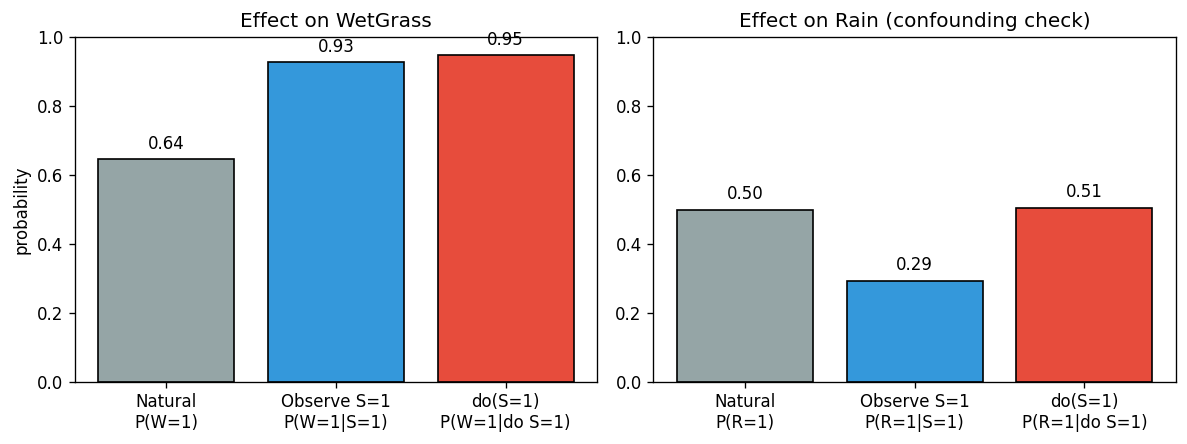

In [5]:
# ── do(Sprinkler=1) via mutilated graph Gibbs ────────────────────────────────
# Cut Cloudy -> Sprinkler: S is fixed to 1, no longer depends on C.

def gibbs_do_sprinkler_on(n_samples=25000, seed=3):
    rng = np.random.default_rng(seed)
    state = {"C": 0, "R": 0, "S": 1, "W": 0}  # S fixed by intervention
    samples = []
    for _ in range(n_samples):
        # C | R  (S no longer child of C under intervention for the S CPT,
        # but C still parents R; W depends on R,S)
        def score_c(c):
            pc = P_C if c == 1 else 1 - P_C
            pr = P_R_given_C[c] if state["R"] == 1 else 1 - P_R_given_C[c]
            return pc * pr
        s0, s1 = score_c(0), score_c(1)
        state["C"] = bern(s1 / (s0 + s1), rng)

        def score_r(r):
            p = P_R_given_C[state["C"]] if r == 1 else 1 - P_R_given_C[state["C"]]
            p *= P_W_given_RS[(r, 1)] if state["W"] == 1 else 1 - P_W_given_RS[(r, 1)]
            return p
        s0, s1 = score_r(0), score_r(1)
        state["R"] = bern(s1 / (s0 + s1), rng)

        state["S"] = 1  # intervention
        state["W"] = bern(P_W_given_RS[(state["R"], 1)], rng)
        samples.append(dict(state))
    return samples

samples_do = gibbs_do_sprinkler_on()
post_do = samples_do[2000:]
p_w_do = np.mean([s["W"] for s in post_do])
p_r_do = np.mean([s["R"] for s in post_do])

# Observational P(W=1 | S=1) for comparison
samples_obs_s = gibbs_sprinkler(n_samples=25000, evidence={"S": 1}, seed=4)
post_os = samples_obs_s[2000:]
p_w_obs = np.mean([s["W"] for s in post_os])
p_r_obs = np.mean([s["R"] for s in post_os])

# Prior / natural P(W=1) via ancestral sampling
def ancestral(n=20000, seed=5):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n):
        c = bern(P_C, rng)
        r = bern(P_R_given_C[c], rng)
        s = bern(P_S_given_C[c], rng)
        w = bern(P_W_given_RS[(r, s)], rng)
        out.append({"C": c, "R": r, "S": s, "W": w})
    return out

nat = ancestral()
p_w_nat = np.mean([s["W"] for s in nat])
p_r_nat = np.mean([s["R"] for s in nat])

print("========== Observational vs Interventional ==========")
print(f"Natural world:          P(W=1)={p_w_nat:.3f}   P(R=1)={p_r_nat:.3f}")
print(f"Observe S=1:            P(W=1|S=1)={p_w_obs:.3f}   P(R=1|S=1)={p_r_obs:.3f}")
print(f"Intervene do(S=1):      P(W=1|do(S=1))={p_w_do:.3f}   P(R=1|do(S=1))={p_r_do:.3f}")
print()
print("Note: P(R|S=1) shifts observationally (common cause Cloudy),")
print("but P(R|do(S=1)) stays near the natural P(R) — intervention cuts the confounding path.")

labels = ["Natural\nP(W=1)", "Observe S=1\nP(W=1|S=1)", "do(S=1)\nP(W=1|do S=1)"]
w_vals = [p_w_nat, p_w_obs, p_w_do]
r_labels = ["Natural\nP(R=1)", "Observe S=1\nP(R=1|S=1)", "do(S=1)\nP(R=1|do S=1)"]
r_vals = [p_r_nat, p_r_obs, p_r_do]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
colors = ["#95A5A6", "#3498DB", "#E74C3C"]
axes[0].bar(labels, w_vals, color=colors, edgecolor="k")
axes[0].set_ylim(0, 1)
axes[0].set_title("Effect on WetGrass")
axes[0].set_ylabel("probability")
for i, v in enumerate(w_vals):
    axes[0].text(i, v + 0.03, f"{v:.2f}", ha="center")

axes[1].bar(r_labels, r_vals, color=colors, edgecolor="k")
axes[1].set_ylim(0, 1)
axes[1].set_title("Effect on Rain (confounding check)")
for i, v in enumerate(r_vals):
    axes[1].text(i, v + 0.03, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig("INF_E_do_calculus.png", dpi=150, bbox_inches="tight")
plt.show()

### Takeaway — do-calculus

| Query | Graph operation | What it answers |
|---|---|---|
| $P(Y \mid X=x)$ | Condition on $X=x$ | "In worlds where $X$ happened, what about $Y$?" |
| $P(Y \mid \mathrm{do}(X=x))$ | Delete edges into $X$, set $X=x$ | "If I *force* $X$, what about $Y$?" |

LLMs trained on observational text approximate the left column. Agents that plan need the right column — that is why causal graphs (or structural world models that implement interventions) are not optional for decision-making.

---

## 6. Bridge to World Models & The Next Phases

```
Belief_Architecture          →  structure of P(world)
Inference (this notebook)    →  compute P(latent | obs) and P(· | do(a))
        │
        ▼
State-Space Models (Phase 4) →  scalable latent dynamics  h_{t+1} = A h_t + B u_t
        │
        ▼
MCTS / Planning (Phase 6)    →  search over interventions a using the model
        │
        ▼
World Models / JEPA (Phase 7)→  learn the model from pixels / sensors
```

**Recipe for a causal agent:**
1. Maintain a belief state $b_t = P(s_t \mid o_{\le t})$ — BP / filtering / amortized encoder.
2. For each candidate action $a$, predict $P(o_{t+1:t+H} \mid \mathrm{do}(a))$ with the world model.
3. Score trajectories (reward / preference), pick $a^*$ (MCTS / MPC).
4. Act, observe, update belief — repeat.

Exact BN inference does not scale to pixels. That is why Phase 4 (SSMs) and Phase 7 (learned world models) exist — but the **semantics** of belief, intervention, and d-separation do not change.

## 7. Concept Map

```
Inference & Causality
│
├── Exact on trees
│   ├── Belief Propagation (sum-product)
│   ├── Forward–Backward (HMM)
│   └── Kalman filter / smoother (Gaussian chain)
│
├── Approximate message passing
│   └── Loopy BP (cycles; no exactness guarantee)
│
├── Sampling (any graph; asymptotic exact)
│   ├── Metropolis–Hastings (general proposals)
│   └── Gibbs (coordinate full conditionals / Markov blanket)
│
└── Causal queries
    ├── Observational conditioning  P(Y|X)
    ├── Intervention do(X)          P(Y|do(X))
    └── Backdoor adjustment when Z blocks backdoors
```

---

## 8. Summary Table

| Concept | Formula / rule | AI relevance |
|---|---|---|
| BP message | $\mu_{i\to j}(x_j)=\sum_{x_i}\phi_i\psi_{ij}\prod_{k\neq j}\mu_{k\to i}$ | Exact filtering on tree latents |
| Belief | $b_i \propto \phi_i \prod_j \mu_{j\to i}$ | Marginal posterior for decisions |
| MH accept | $\min(1, P(x')q(x|x') / [P(x)q(x'|x)])$ | Posterior sampling / EBMs |
| Gibbs | $x_i \sim P(x_i \mid x_{\mathrm{MB}(i)})$ | Local updates; conjugate models |
| Backdoor | $P(Y\mid do(x))=\sum_z P(Y\mid x,z)P(z)$ | Identifiable causal effect |
| Mutilated graph | delete edges into intervened nodes | Implements $\mathrm{do}(\cdot)$ in simulators |

---

## 9. References

- Murphy, K. P. (2022) — *Probabilistic Machine Learning*, Ch. 9–12 (inference).
- Koller & Friedman (2009) — *Probabilistic Graphical Models*, Ch. 9–12.
- Pearl, J. (2000) — *Causality*, Ch. 1–3 (do-calculus, backdoor).
- Pearl, J. (1988) — *Probabilistic Reasoning in Intelligent Systems* (BP origins).
- Neal, R. (1993) — Probabilistic inference using Markov chain Monte Carlo methods.
- Wainwright & Jordan (2008) — *Graphical Models, Exponential Families, and Variational Inference*.

---

## 10. Exercises (do these before Phase 4)

1. **Exact check:** For the 5-node chain, compute $P(X_2 \mid \mathrm{obs})$ by brute-force enumeration ($2^5=32$ states) and verify BP matches.
2. **Treewidth pain:** Add one edge that creates a dense clique of size 6; time variable elimination vs Gibbs.
3. **Backdoor:** Write the backdoor formula for $P(W \mid \mathrm{do}(S))$ with $Z=\{\mathrm{Cloudy}\}$ and estimate each term by ancestral sampling; compare to the mutilated-graph Gibbs result above.
4. **Explaining away:** Condition on $W=1$ and show that $R$ and $S$ become *negatively* dependent (collider).